<center><font size=6>Personal Loan Campaign</font></center>


# **Problem Statement**

### Business Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability
customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset
customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan
business and in the process, earn more through the interest on loans. In particular, the management wants to
explore ways of converting its liability customers to personal loan customers (while retaining them as
depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9%
success. This has encouraged the retail marketing department to devise campaigns with better target
marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify
the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are
most significant in driving purchases, and to identify which segment of customers to target more.

### Data Dictionary

1. **ID**: Customer ID

2. **Age**: Customer’s age in completed years
3. **Experience**: # years of professional experience
4. **Income**: Annual income of the customer (in thousand dollars)
5. **ZIP Code**: Home Address ZIP code.
6. **Family**: The family size of the customer
7. **CCAvg**: Average spending on credit cards per month (in thousand dollars)
8. **Education**: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
9. **Mortgage**: Value of house mortgage if any. (in thousand dollars)
10. **Personal_Loan**: Did this customer accept the personal loan offered in the last campaign?
11. **Securities_Account**: Does the customer have a securities account with the bank?
12. **CD_Account**: Does the customer have a certificate of deposit (CD) account with the bank?
13. **Online**: Do customers use Internet banking facilities?
14. **CreditCard**: Does the customer use a credit card issued by any other Bank (excluding All Life Bank)?

# **Importing the necessary libraries**

In [265]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import math

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)

# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the data**

In [266]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [267]:
#code here to read the data
file = "/content/drive/MyDrive/AIML GL/Machine Learning/Loan_Modelling.csv"
customer_details = pd.read_csv(file)

In [268]:
#keeping a copy of the original data
data = customer_details.copy()

In [269]:
#code to view the first 5 rows
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [270]:
#Code to check how many rows and columns are present in the data
print(data.shape)
print("Rows : ",data.shape[0])
print("Columns : ", data.shape[1])

(5000, 14)
Rows :  5000
Columns :  14


In [271]:
#Code to check the datatypes of the different columns in the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None


Observations:


*   There are 13 integer and 1 float variables in the data.



In [272]:
#Code to check if there are any missing values in the data
print(data.isnull().sum().sum())

0


Observations:

This prints 0(zero), which indicates there are no missing values in the dataset

In [273]:
#Code to check the statistical summary of the data
data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Observations:




*   The minimum income of a customer is - 8 thousand dollars
*   The average income of a customer is - 73 thousand dollars
*   The maximum income of a customer is - 224 thousand dollars
*  The minimum age of customer is 23 years and maximum age is 67 years





# **Exploratory Data Analysis**

### Univariate Analysis

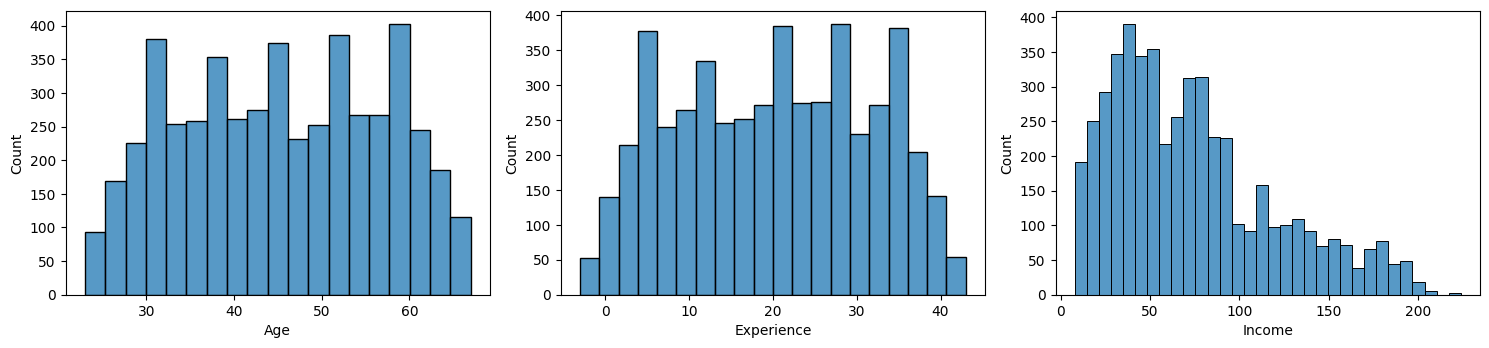

In [274]:
# plotting the histogram for 'Age', 'Experience', 'Income'
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)

plt.tight_layout();   # to add spacing between plots

***Observations:***


*   The age column data seems fairly uniformly distributed but there's a slight dip in frequency at the lower and upper age ranges (mid-20s and 60+).
*   Experience has values less than 0  and in real-world data, negative experience doesn't make logical sense. This is likely due to data entry errors.
*  Income column shows strong right skew with a long tail extending up to 200k+.




In [275]:
#Checking the no. of negative records for Experience column
negative_experience_count = (data['Experience'] < 0).sum()
print(f"Number of records with negative experience: {negative_experience_count}")

Number of records with negative experience: 52


In [276]:
# Replace negative Experience column values with their absolute values
data['Experience'] = data['Experience'].apply(lambda x: abs(x) if x < 0 else x)

In [277]:
# Confirm no negative values remain
print((data['Experience'] < 0).sum())

0


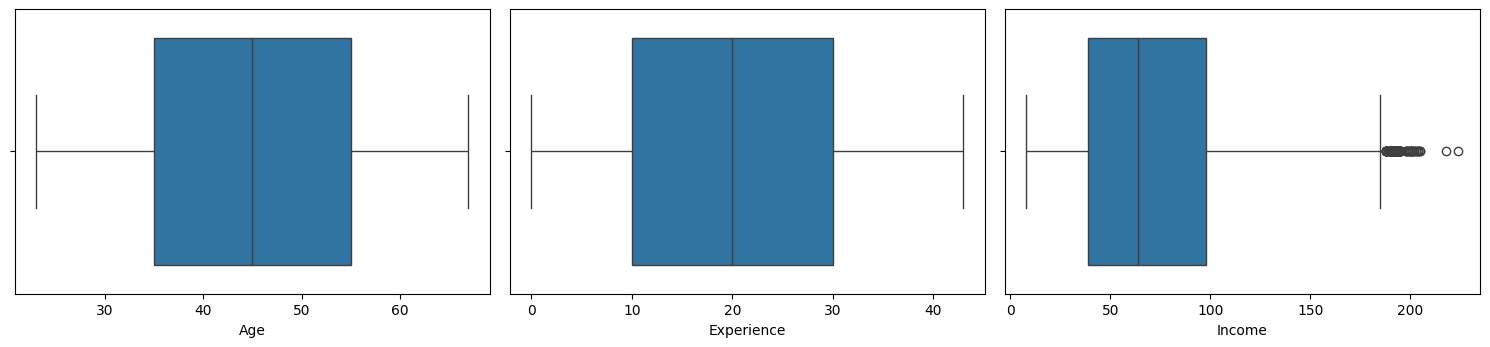

In [278]:
# Plotting the boxplot
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)

plt.tight_layout();    # to add spacing between plots

***Observations:***


*   Age data looks clean, well-distributed, and doesn’t need any cleaning or transformation.
*   For experience data plot, the data looks clean and well-distributed as well.
* The income variable has high-income outliers



Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64 



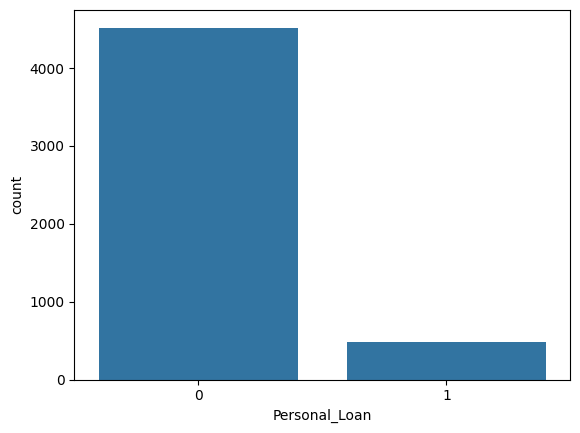

In [279]:
# checking the distribution of the Personal_Loan taken
print(100*data['Personal_Loan'].value_counts(normalize=True), '\n')

# plotting the count plot for Personal_Loan
sns.countplot(data=data, x='Personal_Loan');

***Observations:***


*   90.4% of the people did not take the personal loan
*   Only 9.6% of the customers has taken the personal loan

Securities_Account
0    89.56
1    10.44
Name: proportion, dtype: float64 



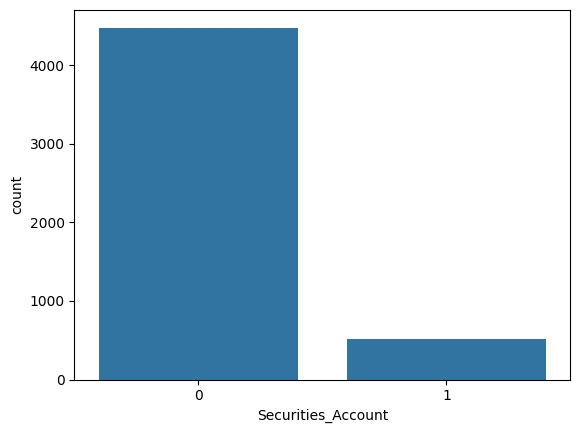

In [280]:
# checking the distribution of the Securities_Account of customers
print(100*data['Securities_Account'].value_counts(normalize=True), '\n')

# plotting the count plot for Personal_Loan
sns.countplot(data=data, x='Securities_Account');

***Observations:***


*  Only 10.44% of the customers have a securities account with the bank.

CD_Account
0    93.96
1     6.04
Name: proportion, dtype: float64 



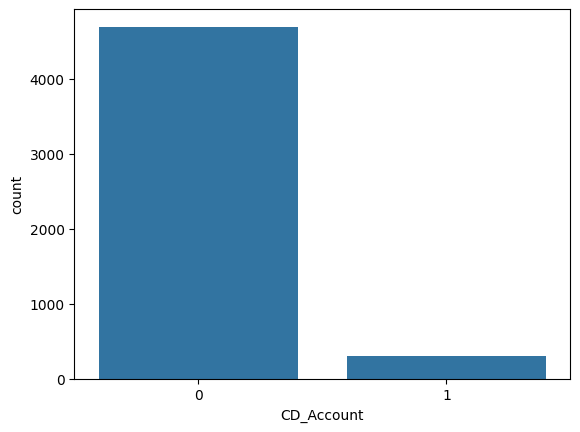

In [281]:
# checking the distribution of the CD_Account of customers
print(100*data['CD_Account'].value_counts(normalize=True), '\n')

# plotting the count plot for Personal_Loan
sns.countplot(data=data, x='CD_Account');

***Observations:***


*  Only 6.04% of the customers have a certificate of deposit (CD) account with the bank.

CreditCard
0    70.6
1    29.4
Name: proportion, dtype: float64 



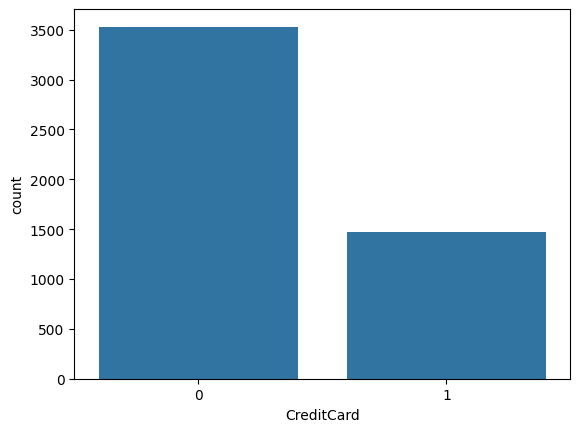

In [282]:
# checking the distribution of the Credit Card of customers
print(100*data['CreditCard'].value_counts(normalize=True), '\n')

# plotting the count plot for Personal_Loan
sns.countplot(data=data, x='CreditCard');

***Observations:***


*  29.4% of the customers have a Credit Card of the bank.

### Bivariate Analysis

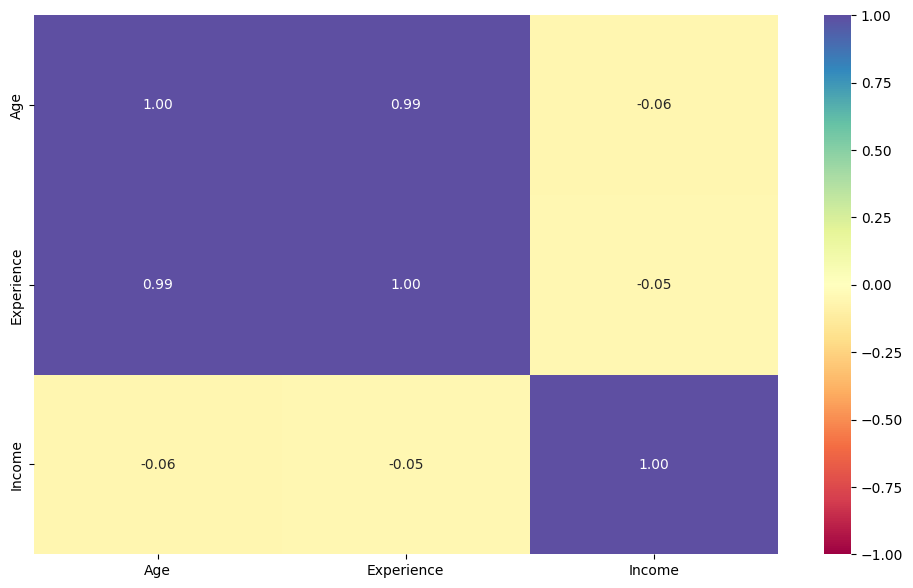

In [283]:
# plotting the heatmap for correlation between the num_features variables
plt.figure(figsize=(12, 7))
sns.heatmap(
    data[['Age','Experience', 'Income']].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

***Observations:***


*  For Age vs Experience : This shows an extremely strong positive correlation of 0.99
* For Age vs Income  and Experience vs Income : These values are close to 0, indicating no significant linear relationship. Neither age nor experience seems to directly impact income in this dataset

<Figure size 1600x1000 with 0 Axes>

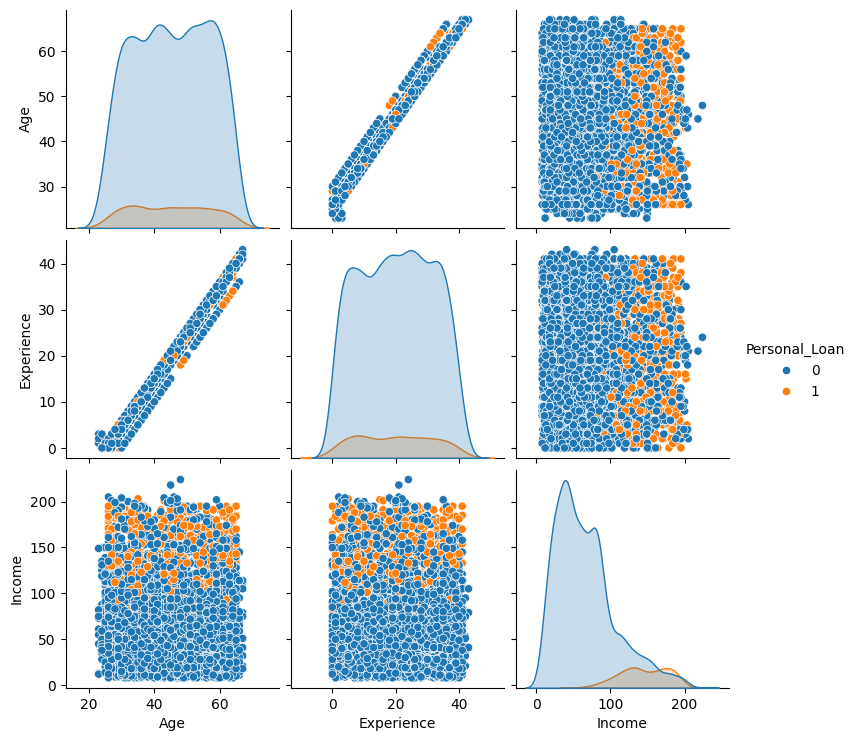

In [284]:
# Plotting Scatter plot matrix between 'Age','Experience', 'Income' features to check their status of Personal loan taken
plt.figure(figsize=(16, 10))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde');

***Observations:***


*  Most orange dots are concentrated at higher income levels. Individuals with income above ~100 (thousand dollars) are more likely to take a personal loan.
* Mid-career individuals with 10–30 years of experience are more likely to take loans
* Very young (<30) or very old (~ >70) people rarely take loans.


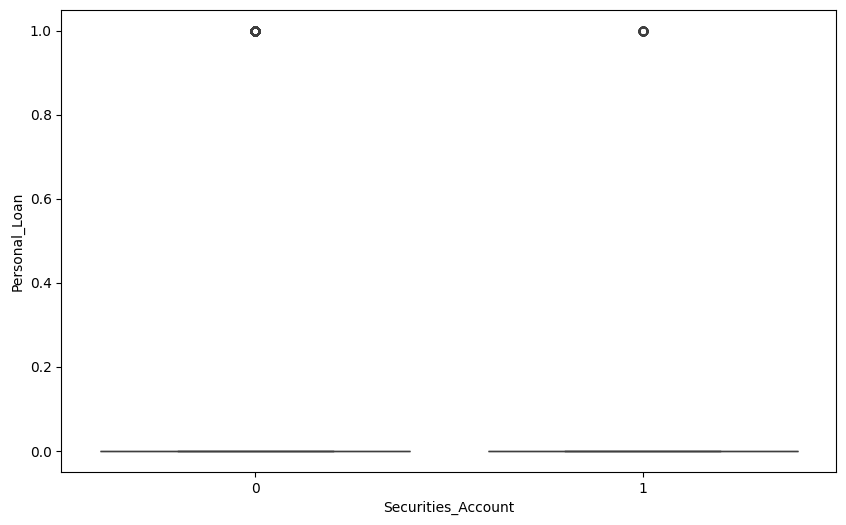

In [285]:
# Securities_Account vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Securities_Account', y='Personal_Loan');

***Observations:***


* The boxplots are extremely flat at Personal_Loan = 0, indicating low uptake overall.
* There are a few outlier points at Personal_Loan = 1 for both Securities_Account = 0 and 1. This means some people took personal loans whether or not they held a securities account, but they are very few.
* There is no clear difference in loan uptake between customers with or without a securities account. Therefore, Securities_Account is not a strong predictor of personal loan behavior.

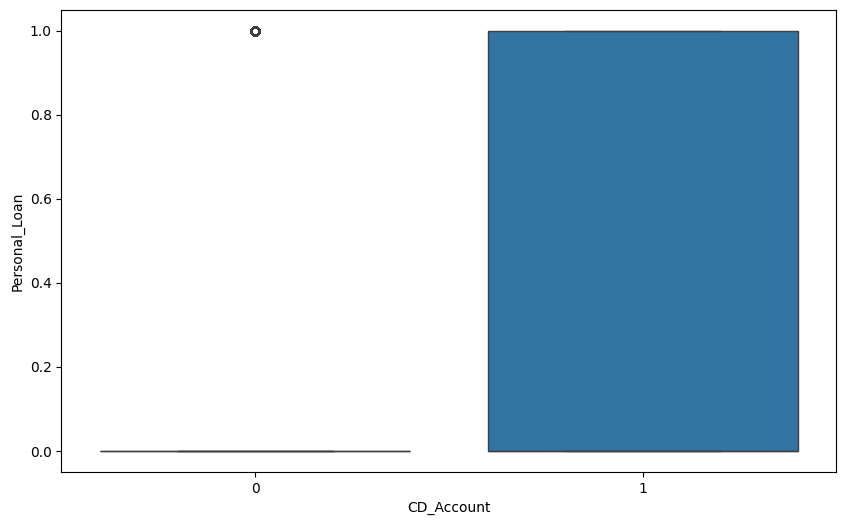

In [286]:
# CD_Account vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='CD_Account', y='Personal_Loan');

***Observations:***


* There is a strong correlation between CD Account and Personal Loan. For customers with CD_Account = 1, the boxplot shows a high value near Personal_Loan = 1, indicating that most of them took personal loans.
* Customers with CD_Account = 0 have almost all values at Personal_Loan = 0, suggesting low interest or eligibility for loans in this group.
* CD_Account is a strong predictor. This visual clearly shows that having a CD account greatly increases the likelihood of taking a personal loan.

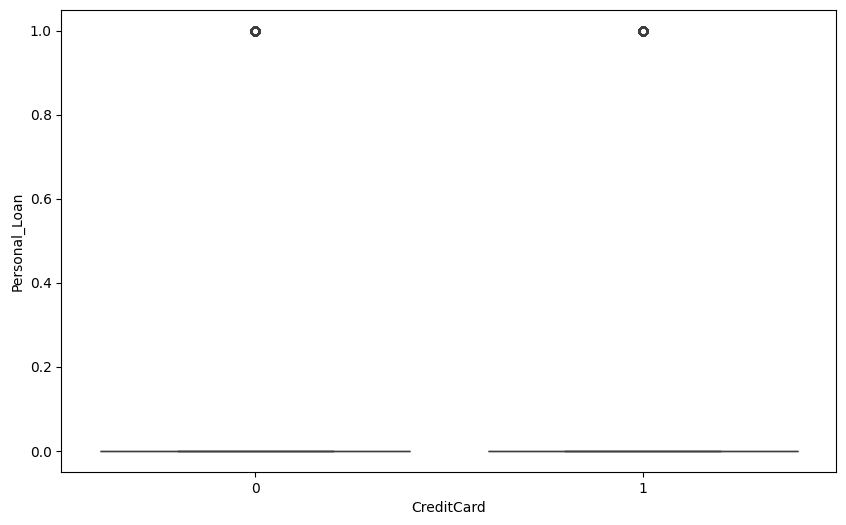

In [287]:
# CreditCard vs Personal_Loan (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='CreditCard', y='Personal_Loan');

***Observations:***


* The boxplots are extremely flat at Personal_Loan = 0, indicating low uptake overall.
* There are a few outlier points at Personal_Loan = 1 for both CreditCard = 0 and 1. This means some people took personal loans whether or not they held a Credit Card, but they are very few.
* There is no clear difference in loan uptake between customers with or without a Credit Card. Therefore, Credit Card is not a strong predictor of personal loan behaviour.

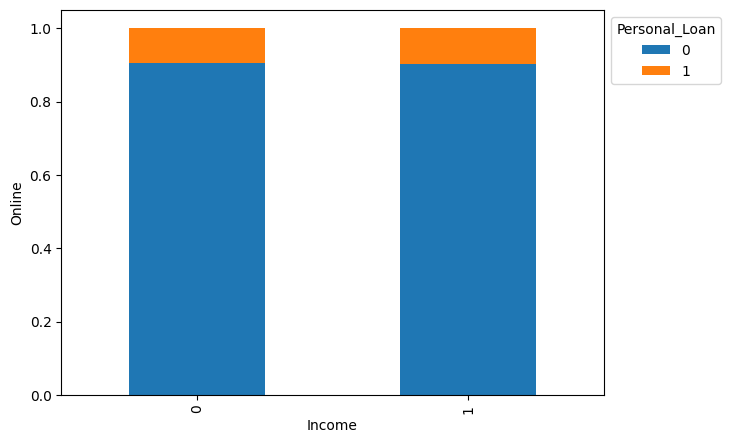

In [288]:
# creating a crosstab for Personal_Loan vs Online
tab = pd.crosstab(
    data['Online'],
    data['Personal_Loan'],
    normalize='index'    # normalizing by dividing each row by its row total
).sort_values(by=0, ascending=False)    # sorting the resulting crosstab


# Plot the stacked bar chart
tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
plt.xlabel('Income')
plt.ylabel('Online')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Personal_Loan');

***Observations:***


* Minimal difference between Online vs Non-Online users:

  - Both bars (for Online = 0 and Online = 1) show a very similar proportion of personal loan takers (orange section).

  - This indicates that whether a customer uses online banking or not does not significantly affect their likelihood of taking a personal loan.


# **Data Preparation for Modeling**

### Outlier Detection

**Checking for outliers in the data.**

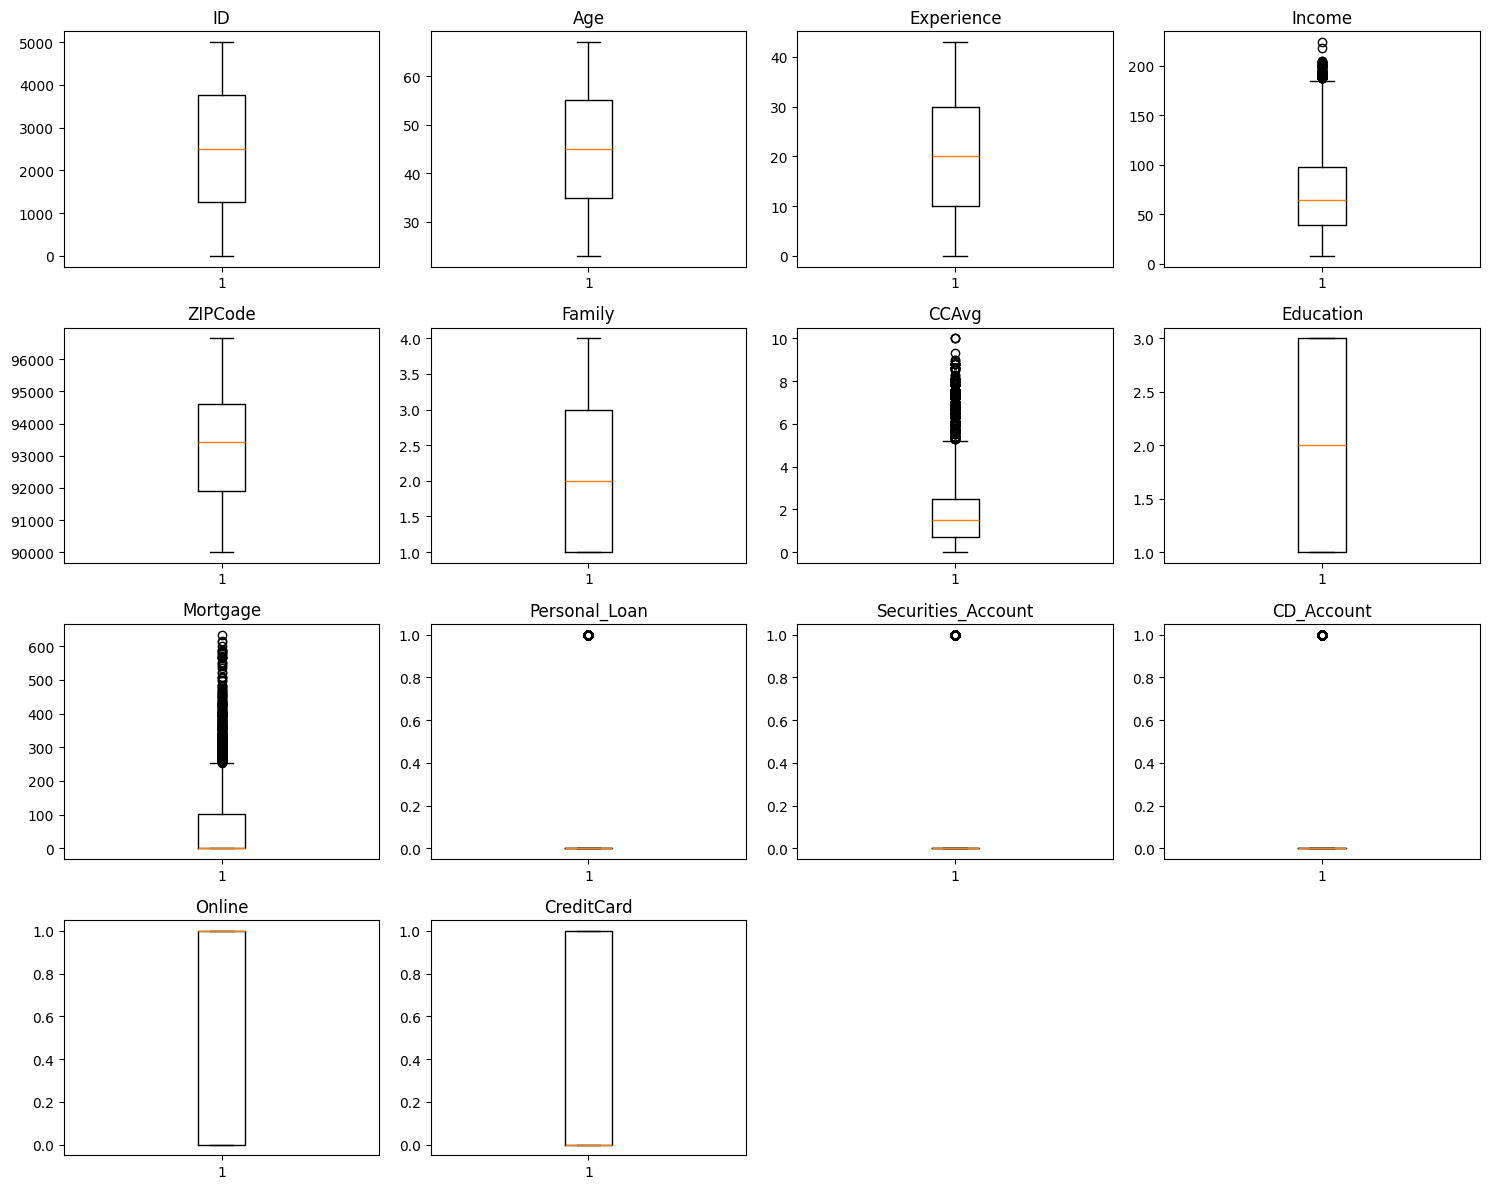

In [289]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

***Observations:***


* Income, CCAvg, and Mortgage show high skewness and outliers.
* CD_Account and Securities_Account are highly imbalanced.
* Personal_Loan is also imbalanced — this is the target, so this needs specific strategies during model training.

### Data Preprocessing

In [290]:
#Setting data for X and Y
X = data.drop(["Personal_Loan"], axis=1)
Y = data["Personal_Loan"]

**Creating training and test sets.**

In [291]:
# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [292]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 13)
Shape of test set :  (1500, 13)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


***Observations:***

* We can seen here that around 90.54% of observations belongs to class 0 (Not Taken) and 9.45% observations belongs to class 1 (Taken Personal Loan), and this is preserved in the train and test sets.

## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. Predicting a liability customer will buy personal loans but in reality the customer would not buy it.

2. Predicting a liability customer will not buy personal loans but in reality the customer would buy it.

**Which case is more important?**

* If we predict a non eligible customer as an eligible customer, bank would lose an opportunity of providing loan to a potential customer.

**How to reduce this loss (i.e., need to increase Precision / True Positives?**
*  To minimize the loss caused by mistakenly identifying a customer as eligible when they are not (i.e., false positives), we need to focus on increasing Precision. Precision emphasizes ensuring that when the model predicts a customer will buy a personal loan, it is highly likely to be correct. This reduces the number of ineligible customers incorrectly flagged as potential buyers. A higher precision means fewer false leads for the sales team, saving cost and effort. Therefore, to reduce incorrect targeting and maximize actual conversions, the model should aim to increase precision by reducing false positives.

In [293]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [294]:
#defining confusion matrix code
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Decision Tree (default)

In [295]:
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Checking model performance on training set

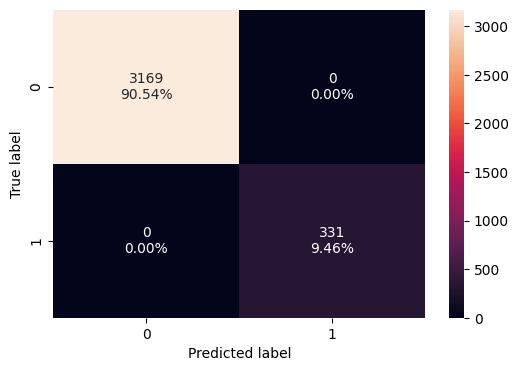

In [296]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [297]:
decision_tree_default_perf_train = model_performance_classification_sklearn(
    model0, X_train, y_train
)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


#### Checking model performance on test set

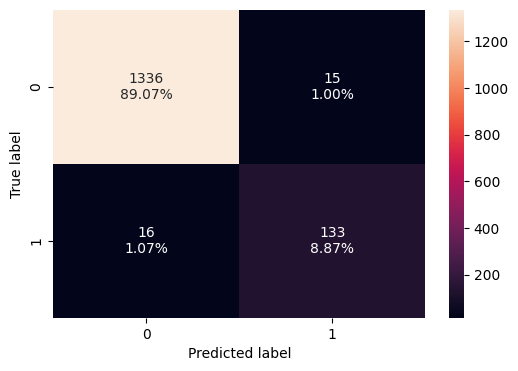

In [298]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [299]:
decision_tree_default_perf_test = model_performance_classification_sklearn(
    model0, X_test, y_test
)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.979333,0.892617,0.898649,0.895623


***Observations:***

* The model performs perfectly on the training data, with no misclassifications.

* This is a strong indicator of overfitting, as it might be memorizing training data rather than generalizing patterns.
* While performance on the test set is still very good, we observe:

  - 16 false negatives, meaning 16 actual buyers were predicted as non-buyers.

 - 15 false positives, meaning 15 non-buyers were incorrectly predicted to buy.

 - Recall is slightly lower than precision, indicating that some real buyers are being missed.

#### Visualizing the Decision Tree

In [300]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


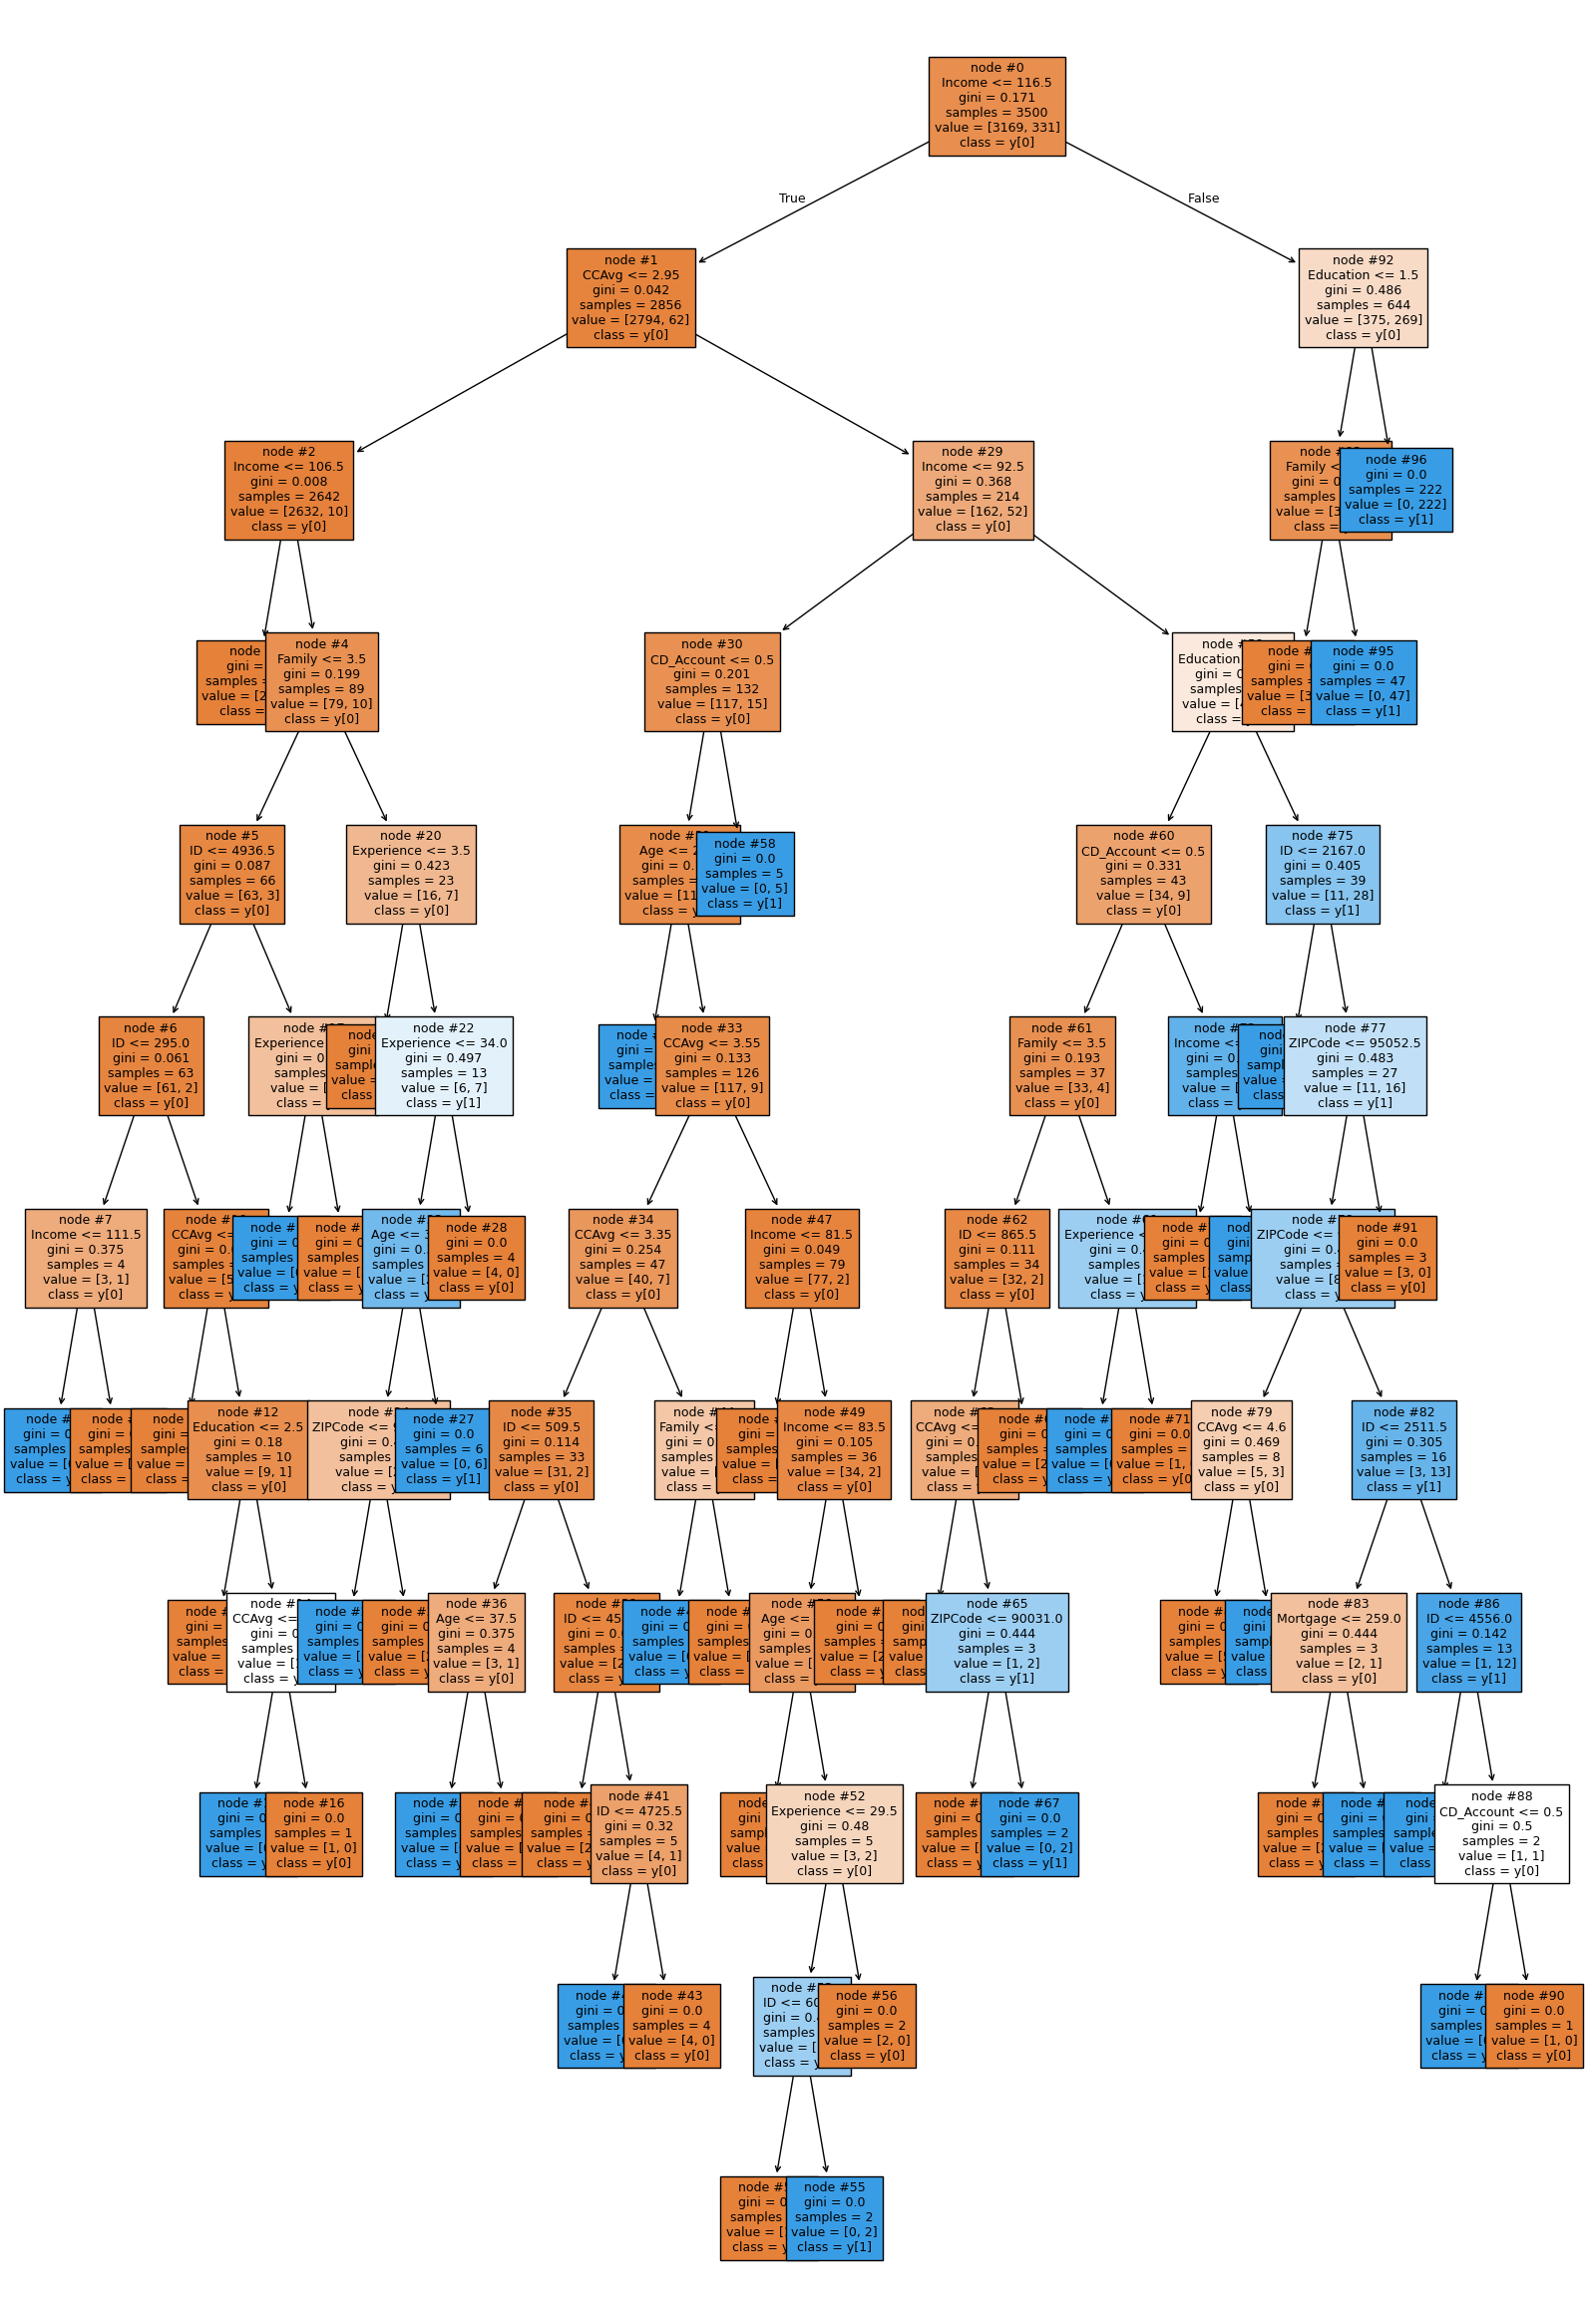

In [301]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model0,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

Observation :
We can see that the model has captuted too much noise.

In [302]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model0, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- ID <= 4936.50
|   |   |   |   |   |--- ID <= 295.00
|   |   |   |   |   |   |--- Income <= 111.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- Income >  111.50
|   |   |   |   |   |   |   |--- weights: [3.00, 0.00] class: 0
|   |   |   |   |   |--- ID >  295.00
|   |   |   |   |   |   |--- CCAvg <= 2.20
|   |   |   |   |   |   |   |--- weights: [49.00, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  2.20
|   |   |   |   |   |   |   |--- Education <= 2.50
|   |   |   |   |   |   |   |   |--- weights: [8.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Education >  2.50
|   |   |   |   |   |   |   |   |--- CCAvg <= 2.65
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |--- 

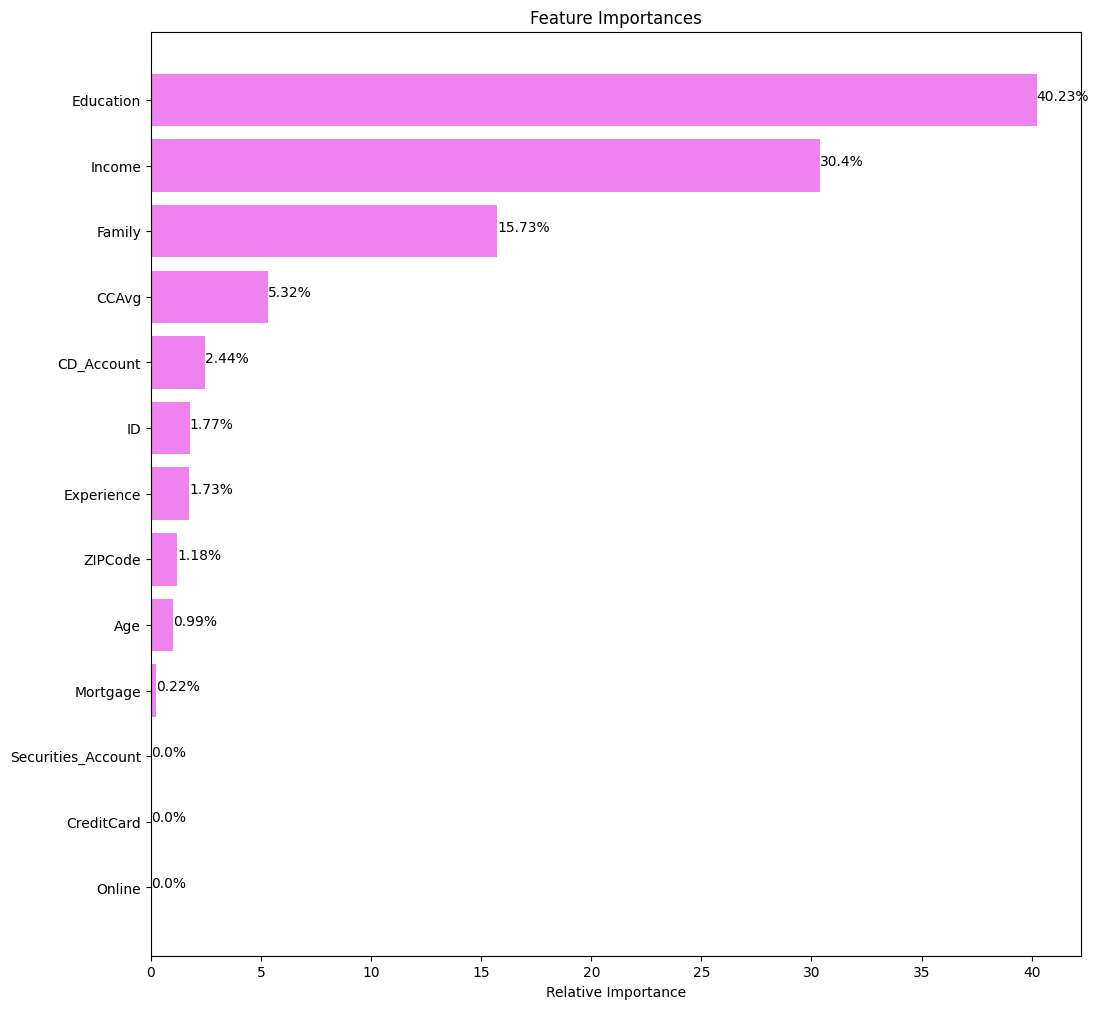

In [303]:
#Code to check importance of the features in the dataset
importances_model0 = pd.DataFrame(model0.feature_importances_ * 100, index=X.columns.to_list(), columns=["Importance%"])
importances_model0 = importances_model0.sort_values(by="Importance%", ascending=True) # sorting the data

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.xlabel("Relative Importance")
plt.barh(importances_model0.index, importances_model0["Importance%"], color="violet", align="center")
for index, value in enumerate(importances_model0["Importance%"]):
    plt.text(value, index, str(round((value), 2)) + "%")
plt.show()

***Observations:***
* Education, Income, family and CAvg are the topmost important features.

### Decision Tree (Pre-pruning)

* Hyperparameter tuning is crucial because it directly affects the performance of a model.
* Unlike model parameters which are learned during training, hyperparameters need to be set before training.
* Effective hyperparameter tuning helps in improving the performance and robustness of the model.
* The below custom loop for hyperparameter tuning iterates over predefined parameter values to identify the best model based on the precision metric.

#### Pre-pruning

In [304]:
# Define the parameters of the tree to iterate over
max_depth_values = [3, 4, 5, 6, 7, 8, 10]
max_leaf_nodes_values = [5, 10, 15, 20, 25, 30]
min_samples_split_values = [10, 20, 30, 40, 50, 60]
min_samples_leaf_values = [3, 5, 10, 20, 25]

# Initialize variables to store the best model and its performance
best_estimator = None

#Minimum test train F1 difference
best_score_diff = float('inf')

#Best precision score for test
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
  for min_samples_split in min_samples_split_values:
    for min_samples_leaf in min_samples_leaf_values:
      for max_leaf_nodes in max_leaf_nodes_values:

            # Initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            )

            # Fit the model to the training data
            estimator.fit(X_train, y_train)

            # Make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Calculate precision scores for training and test sets
            train_precision_score = precision_score(y_train, y_train_pred)
            test_precision_score = precision_score(y_test, y_test_pred)

            # Calculate the absolute difference between training and test recall scores
            score_diff = abs(train_precision_score - test_precision_score)

            # Update the best estimator and best score if the current one has a smaller score difference
            if (score_diff < best_score_diff) & (test_precision_score > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_precision_score
                best_estimator = estimator

# creating an instance of the best model
pre_pruned_model = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Score difference: {best_score_diff}")
print(f"Best test precision score: {best_test_score}")

Best parameters found:
Max depth: 3
Max leaf nodes: 5
Min samples split: 10
Score difference: 0.0
Best test precision score: 1.0


In [305]:
# creating an instance of the best model
pre_pruned_model = best_estimator

# fitting the best model to the training data
pre_pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=5, min_samples_leaf=3,
                       min_samples_split=10, random_state=42)

#### Checking pre-pruned tree performance on training set

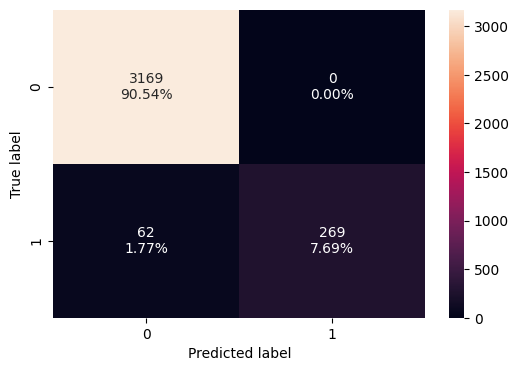

In [306]:
confusion_matrix_sklearn(pre_pruned_model, X_train, y_train)

***Observations:***

* The model makes no false positive predictions for class 1. This is ideal scenario here as our goal is to maximize precision.
* Earlier, the default tree showed 100% on training, likely due to overfitting. This pruned model generalizes better but is more conservative in predicting class 1.

In [307]:
decision_tree_pre_pruned_perf_train = model_performance_classification_sklearn(
    pre_pruned_model, X_train, y_train
)
decision_tree_pre_pruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.982286,0.812689,1.0,0.896667


***Observations:***

* The model does not misclassify any negatives as positives which can be seen from the precision score
* The F1 score 0.89 indicates a good balance between precision and recall.

#### Checking pre-pruned tree model performance on test set

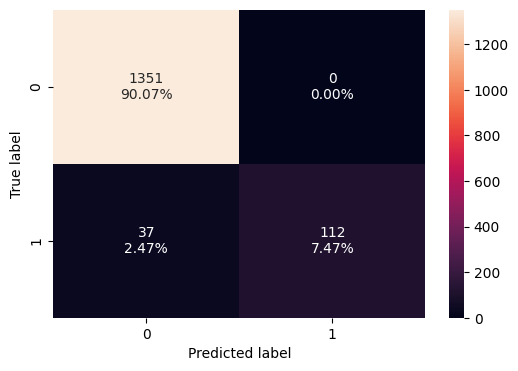

In [308]:
confusion_matrix_sklearn(pre_pruned_model, X_test, y_test)

***Observations:***

* Zero False Positives : Again, the model does not classify any negative (class 0) as positive (class 1).
* Since there are no false positives, precision remains perfect.

In [309]:
decision_tree_pre_pruned_perf_test = model_performance_classification_sklearn(
    pre_pruned_model, X_test, y_test
)

decision_tree_pre_pruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.975333,0.751678,1.0,0.858238


***Observations:***

* The model makes no false positive errors on the test set. All instances predicted as class 1 are actually class 1.
* Recall score shows the model is conservative in flagging positives (likely due to pre-pruning), which helps avoid false positives.

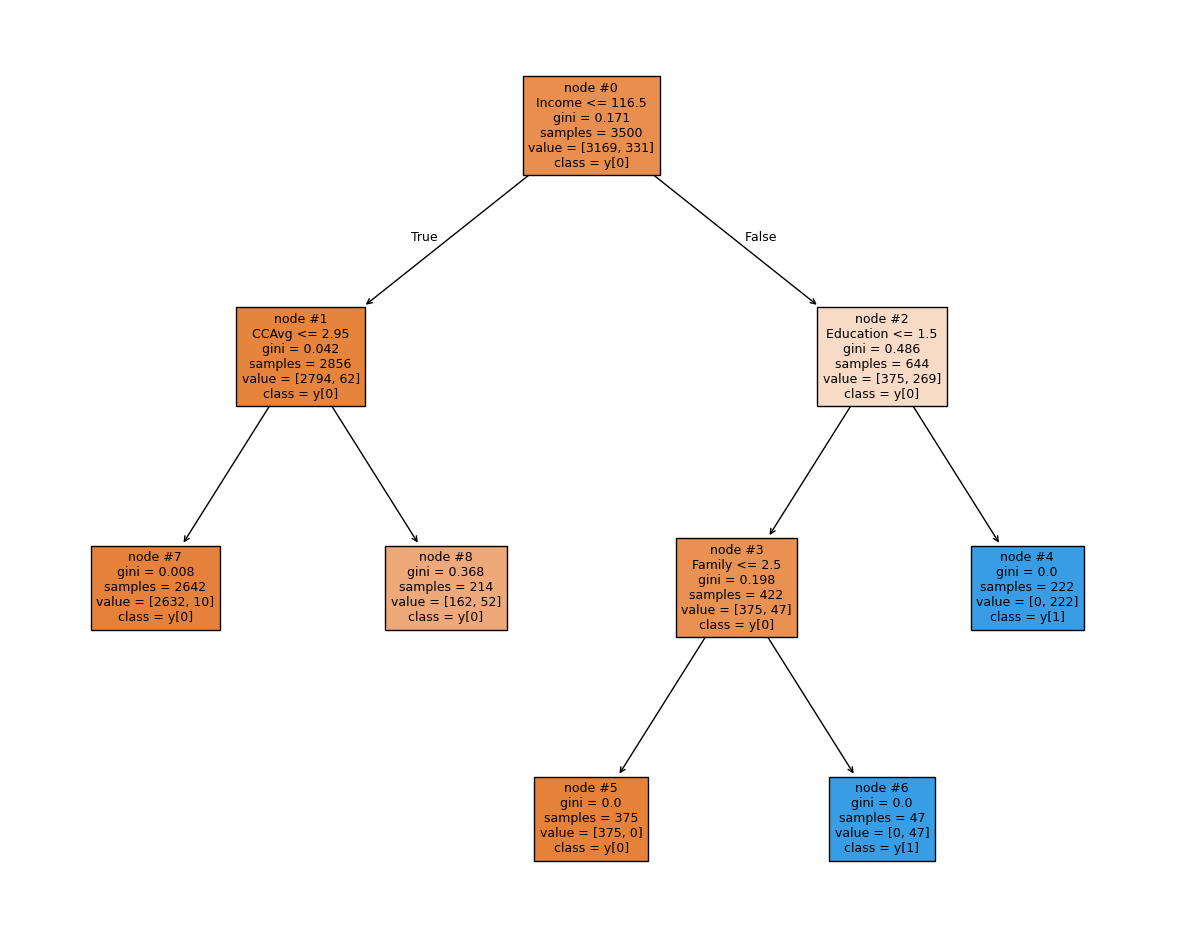

In [310]:
plt.figure(figsize=(15, 12))

tree.plot_tree(
    pre_pruned_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

* We are getting a simplified tree after pre-pruning.

#### Visualizing the Decision Tree

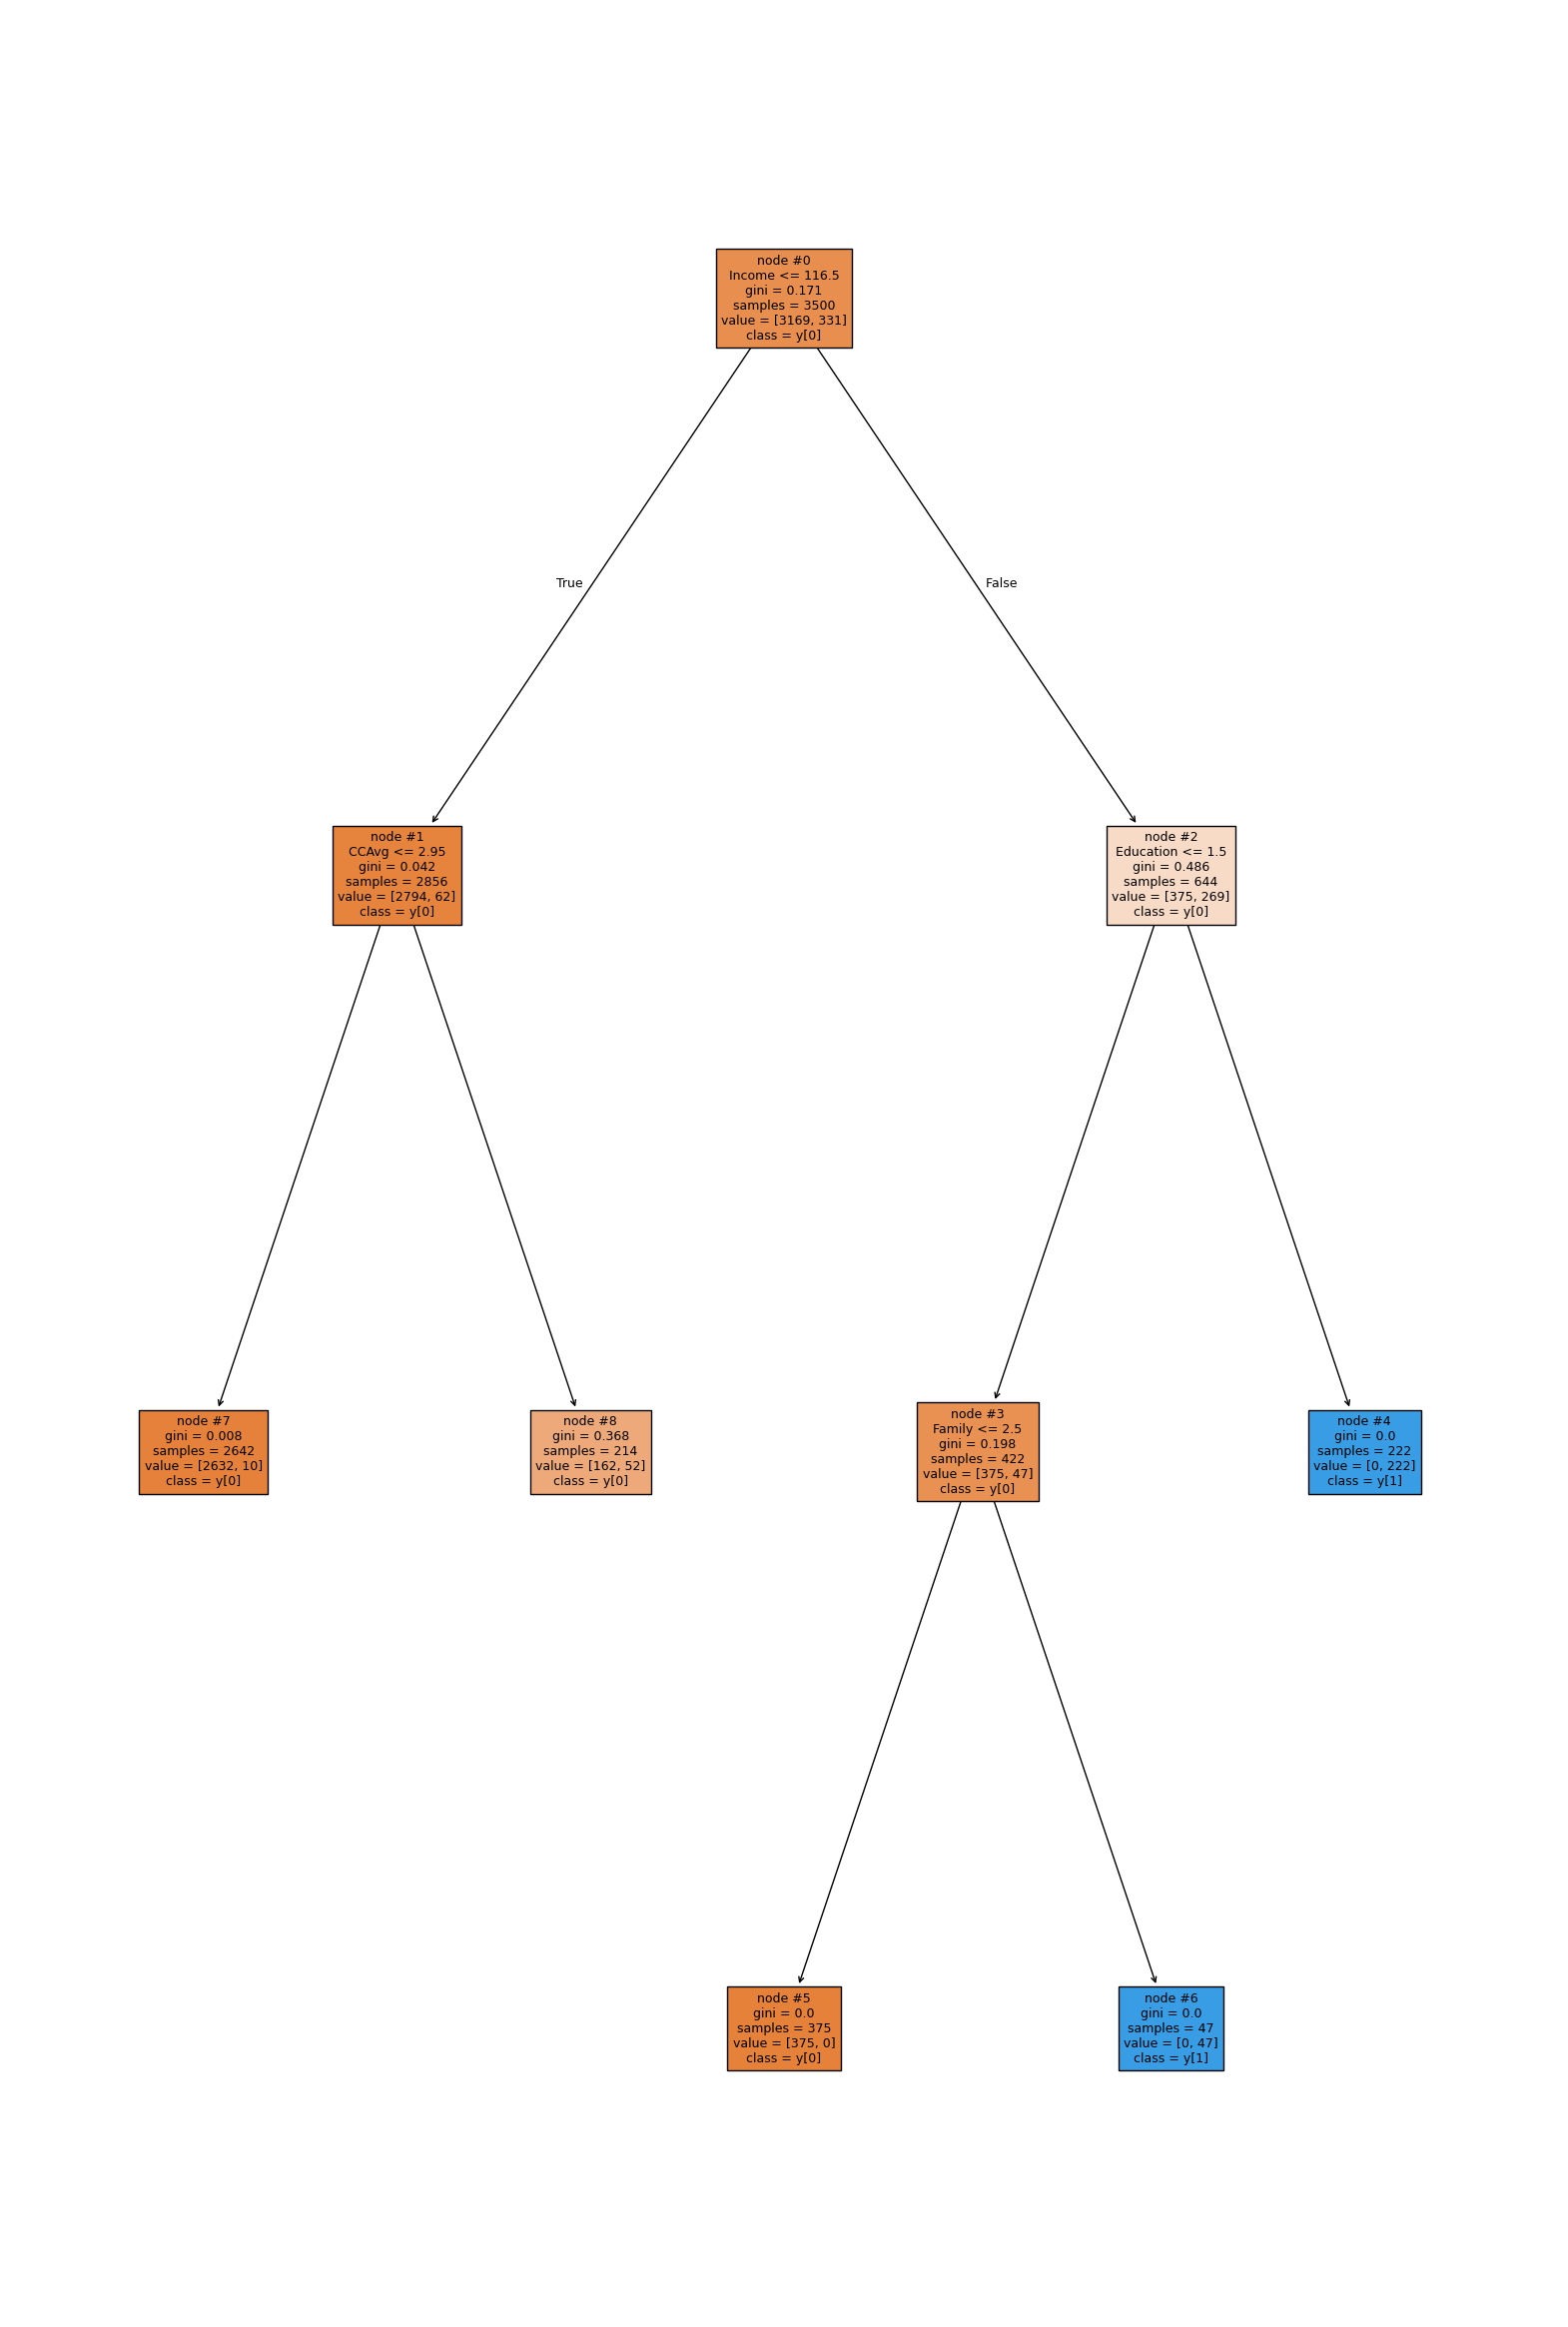

In [311]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    pre_pruned_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [312]:
# Text report showing the rules of a decision tree -

print(tree.export_text(pre_pruned_model, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2632.00, 10.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [162.00, 52.00] class: 0
|--- Income >  116.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [375.00, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [0.00, 47.00] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [0.00, 222.00] class: 1



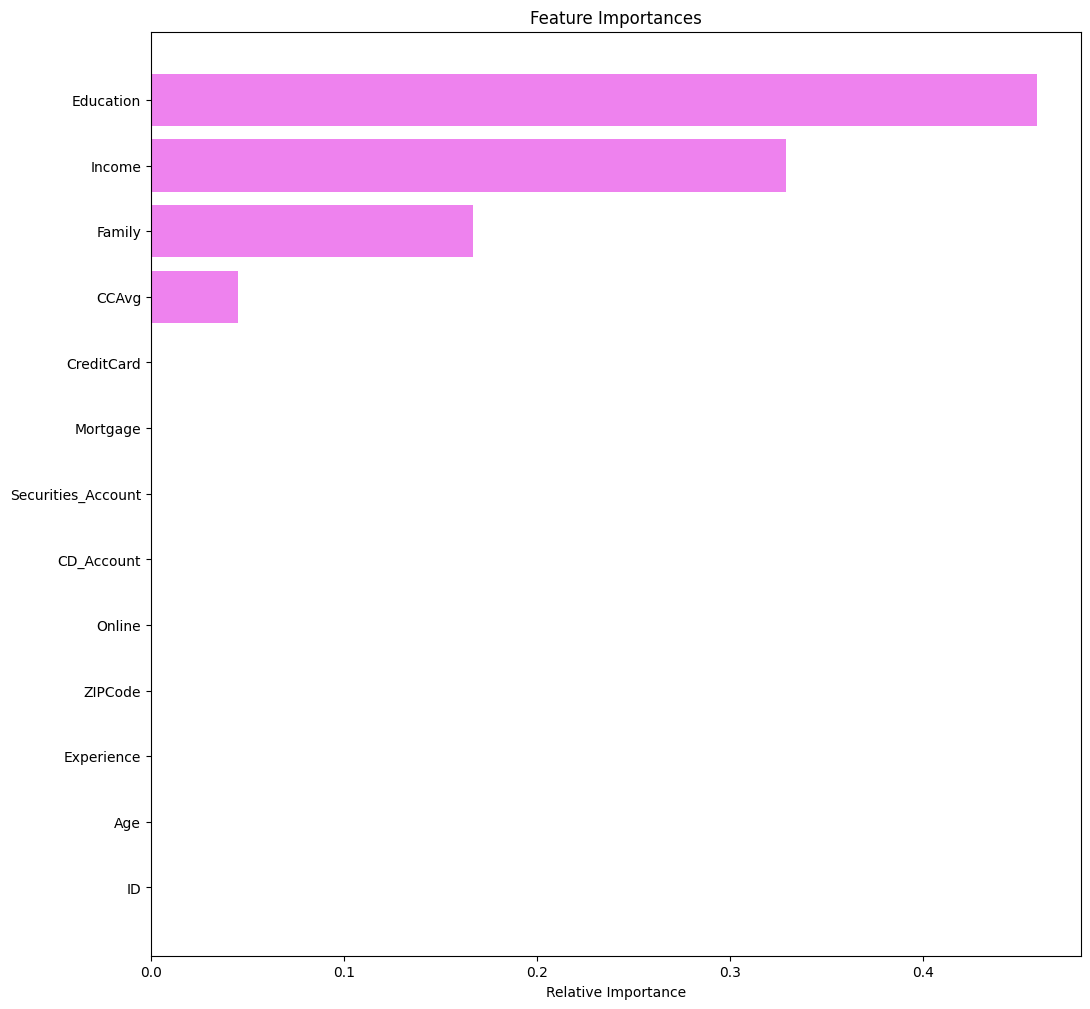

In [313]:
importances = pre_pruned_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the pre-pruned decision tree -  Education, Income, Family, CCAvg are the most important features.

### Decision Tree (Post pruning)

- Cost complexity pruning provides another option to control the size of a tree.
- In `DecisionTreeClassifier`, this pruning technique is parameterized by the
cost complexity parameter, ``ccp_alpha``.
- Greater values of ``ccp_alpha`` increase the number of nodes pruned.
- Here we only show the effect of ``ccp_alpha`` on regularizing the trees and how to choose the optimal ``ccp_alpha`` value.

**Total impurity of leaves vs effective alphas of pruned tree**

Minimal cost complexity pruning recursively finds the node with the "weakest
link". The weakest link is characterized by an effective alpha, where the
nodes with the smallest effective alpha are pruned first. To get an idea of
what values of ``ccp_alpha`` could be appropriate, scikit-learn provides
`DecisionTreeClassifier.cost_complexity_pruning_path` that returns the
effective alphas and the corresponding total leaf impurities at each step of
the pruning process. As alpha increases, more of the tree is pruned, which
increases the total impurity of its leaves.

In [314]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [315]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000187,0.000562
2,0.000223,0.001676
3,0.000264,0.002203
4,0.000268,0.003277
5,0.000269,0.004351
6,0.000359,0.005427
7,0.000381,0.005808
8,0.000381,0.006189
9,0.000381,0.006570


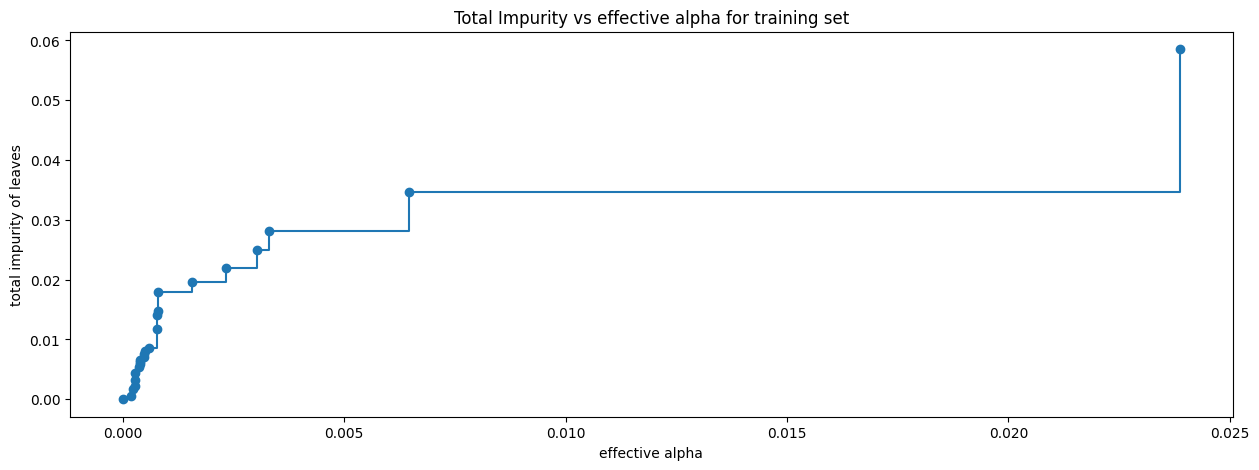

In [316]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Next, we train a decision tree using the effective alphas. The last value in ccp_alphas is the alpha value that prunes the whole tree, leaving the tree, clfs[-1], with one node.

In [317]:
# To store decision tree classifier
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha) # Pruning applied here
    clf.fit(X_train, y_train) # Model is fit with training data
    clfs.append(clf) #Storing model here
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.056364969335601575



For the remainder, we remove the last element in
``clfs`` and ``ccp_alphas``, because it is the trivial tree with only one
node. Here we show that the number of nodes and tree depth decreases as alpha
increases.

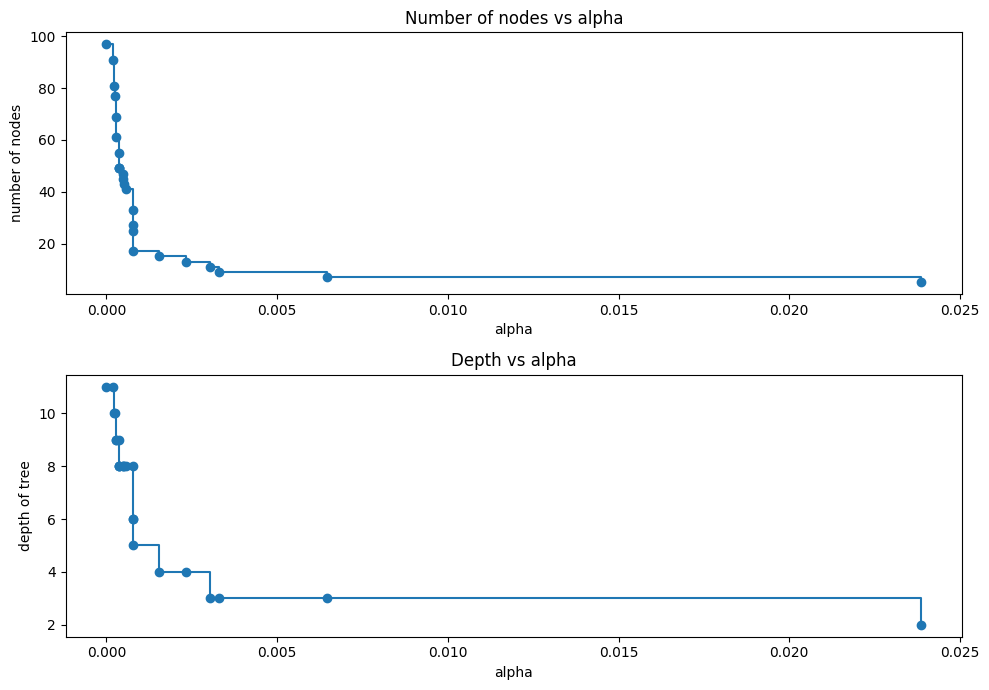

In [318]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

#Fetch node counts and depth
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
# Plotting tree depth along with alpha
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#### Precision vs alpha for training and testing sets

In [319]:
#List to store precision score for the training set of decision tree classifier
precision_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    #Calculating the precision score for the training set predictions
    values_train = precision_score(y_train, pred_train)
    precision_train.append(values_train)

In [320]:
#List to store precision score for the test set of decision tree classifier
precision_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    #Calculating the precision score for the training set predictions
    values_test = precision_score(y_test, pred_test)
    precision_test.append(values_test)

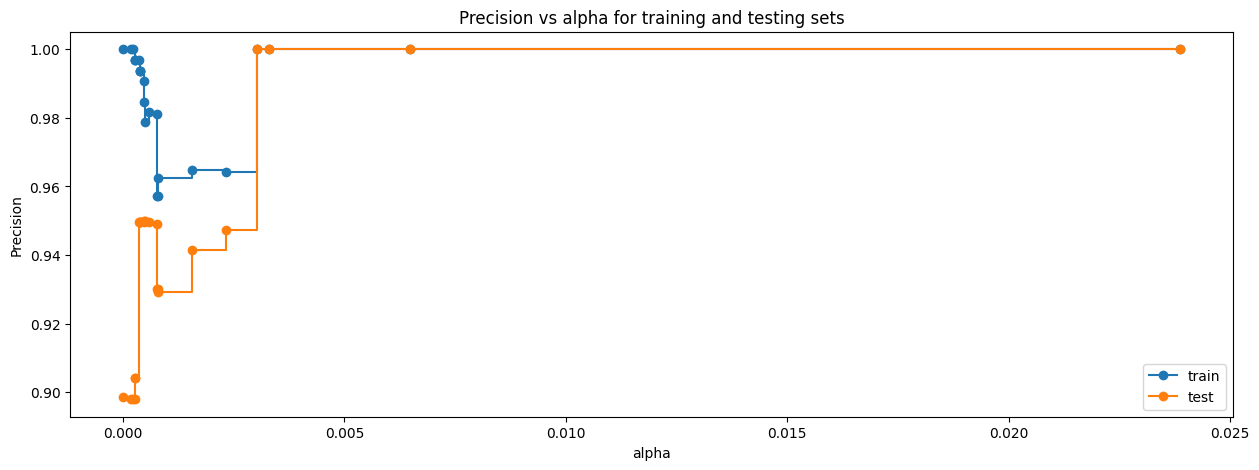

In [321]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Precision")
ax.set_title("Precision vs alpha for training and testing sets")
ax.plot(ccp_alphas, precision_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, precision_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

***Observations:***

* Training Set Precision:

 - Starts at 1.0 when alpha = 0, indicating perfect precision

 - Slight decline as alpha increases — precision dips to around 0.96–0.98 as the tree is pruned.

 - Stabilizes with minimal degradation, which is expected with proper pruning.

* Testing Set Precision:

 - Begins lower (~0.90) at small alpha but rises sharply with pruning — improves to ~0.95 in the alpha ≈ 0.001 to 0.003 range.

 - Peaks at ~1.0 around alpha ≈ 0.0032 to 0.006, suggesting good precision at these pruning levels.

Checking the best decision tree :

In [322]:
# creating the model where we get the highest test precision score
index_best_model = np.argmax(precision_test)
best_model = clfs[index_best_model]
print("best model  value: ",best_model)

best model  value:  DecisionTreeClassifier(ccp_alpha=np.float64(0.003023521760901227),
                       random_state=1)


In [323]:
post_pruned_tree_model = clfs[index_best_model]
post_pruned_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.003023521760901227),
                       random_state=1)

#### Checking post-pruned tree performance on training set

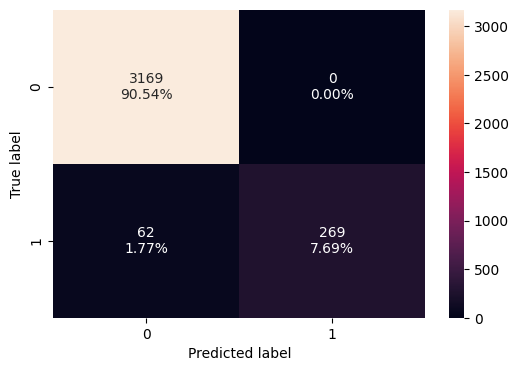

In [324]:
confusion_matrix_sklearn(post_pruned_tree_model, X_train, y_train)

***Observations:***

* We have 0% false positives(which is very good) and 1.77% of False negatives on our training set.

In [325]:
decision_tree_post_pruned_perf_train = model_performance_classification_sklearn(
    post_pruned_tree_model, X_train, y_train
)

decision_tree_post_pruned_perf_train

,Accuracy,Recall,Precision,F1
0,0.982286,0.812689,1.0,0.896667


***Observations:***

* We got Precision here as 1 and F1 score is also good showing about 89%.
* Accuracy is showing about 98%.

#### Checking post-pruned tree performance on training set

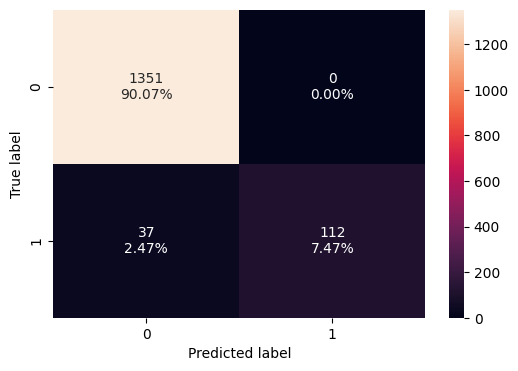

In [326]:
confusion_matrix_sklearn(post_pruned_tree_model, X_test, y_test)

***Observations:***

* We have 0% false positives(which is very good) and 2.47% of False negatives on our test set.

In [327]:
decision_tree_post_pruned_perf_test = model_performance_classification_sklearn(
    post_pruned_tree_model, X_test, y_test
)
decision_tree_post_pruned_perf_test

,Accuracy,Recall,Precision,F1
0,0.975333,0.751678,1.0,0.858238


***Observations:***

* We got Precision here as 1 and F1 score is also good showing about 85% as compared to training data of 89%.
* Accuracy is showing about 97% compared to training data showing 98%.

#### Visualizing the Decision Tree

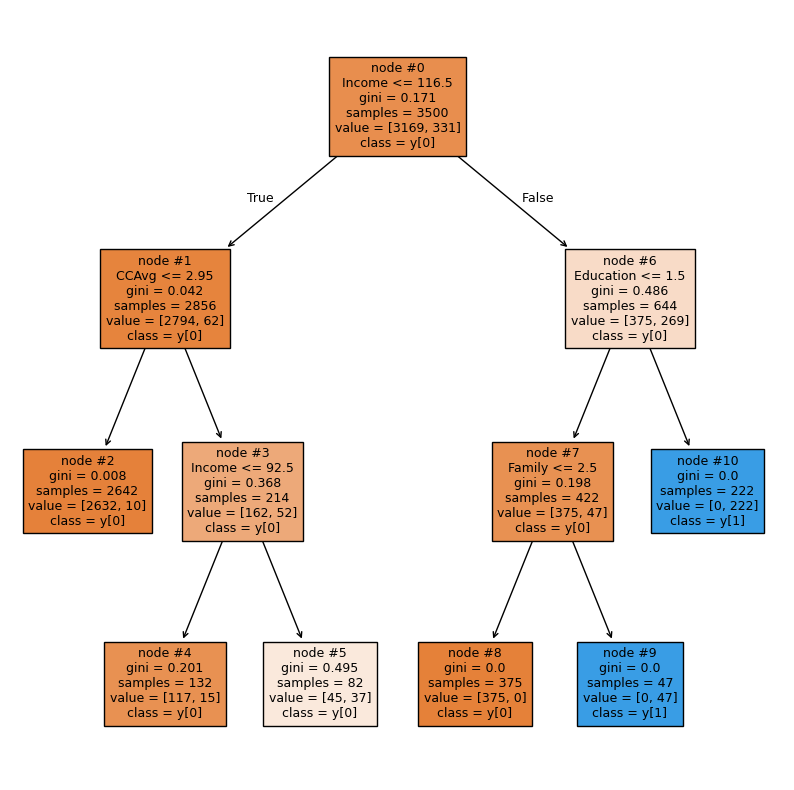

In [328]:
plt.figure(figsize=(10, 10))

out = tree.plot_tree(
    post_pruned_tree_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()
plt.show()

In [329]:
# Text report showing the rules of post pruned decision tree -
print(tree.export_text(post_pruned_tree_model, feature_names=feature_names, show_weights=True))

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2632.00, 10.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- Income <= 92.50
|   |   |   |--- weights: [117.00, 15.00] class: 0
|   |   |--- Income >  92.50
|   |   |   |--- weights: [45.00, 37.00] class: 0
|--- Income >  116.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [375.00, 0.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- weights: [0.00, 47.00] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [0.00, 222.00] class: 1



In [330]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        post_pruned_tree_model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                         Imp
Education           0.448486
Income              0.344228
Family              0.163061
CCAvg               0.044225
ID                  0.000000
ZIPCode             0.000000
Experience          0.000000
Age                 0.000000
Mortgage            0.000000
Securities_Account  0.000000
CD_Account          0.000000
Online              0.000000
CreditCard          0.000000


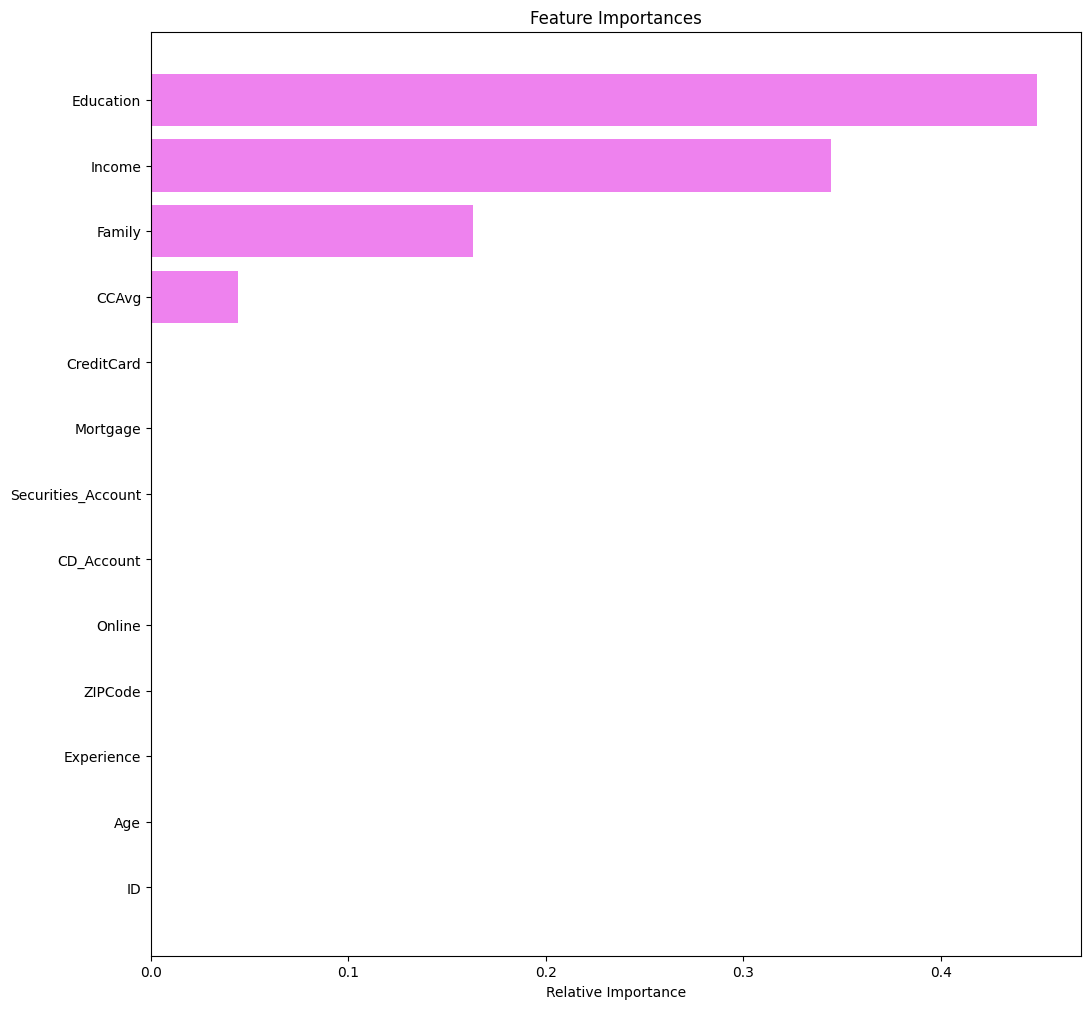

In [331]:
importances = post_pruned_tree_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* In the post-pruned decision tree - Education, Income, Family, CCAvg are the most important features.

## Model Performance Comparison and Final Model Selection

In [332]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_pre_pruned_perf_train.T,
        decision_tree_post_pruned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.982286,0.982286
Recall,1.0,0.812689,0.812689
Precision,1.0,1.000000,1.000000
F1,1.0,0.896667,0.896667


In [333]:
# test performance comparison

models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_pre_pruned_perf_test.T,
        decision_tree_post_pruned_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_train_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.979333,0.975333,0.975333
Recall,0.892617,0.751678,0.751678
Precision,0.898649,1.000000,1.000000
F1,0.895623,0.858238,0.858238


# Decision Tree Model Performance Analysis

## Training vs. Test Performance Comparison

### Default Decision Tree (Unpruned):
- **Training**: Perfect scores (1.0) in all metrics → clear overfitting
- **Test**:
  - Accuracy (0.979) remains strong but drops slightly
  - Recall drops significantly from 1.0 → 0.893
  - Precision remains high (0.899)
  - Shows the expected generalization gap from overfitting

### Pre-Pruned and Post-Pruned Trees:
- **Training**: Both showed identical reduced performance (0.982 accuracy)
- **Test**:
  - Maintain nearly identical performance (0.975 accuracy)
  - Recall drops further to 0.752 (but more honest performance)
  - Perfect precision (1.0) - zero false positives
  - Better F1 score balance than default tree

## Model Selection Recommendation

**Here, we can choose either the Pre-Pruned or Post-Pruned tree** (they perform identically here).  Reasons:

1. **Better Generalization**: While the default tree has higher test recall (0.893 vs 0.752), its training performance (1.0) shows overfitting that could fail on new data.

2. **Perfect Precision**: The pruned trees achieve 100% precision (no false positives) which is valuable in many real-world applications.

3. **More Honest Metrics**: The pruned trees show consistent performance between training and test sets, suggesting they've learned generalizable patterns rather than memorizing training data.

4. **Similar Simplicity**: Since pre and post-pruning achieve identical results, we can choose based on implementation preference
5. As pre-pruning is generally simpler and captures the feature well, it would be better if we go ahead with the pre-pruned model.

## Conclusions and Recommendations

###Conclusions -

## Actionable Insights:
* Key Predictive Attributes:
 - Income Level: Customers with higher income levels have shown significant potential for purchasing personal loans.

 - Credit Card Average Spend (CCAvg): Customers with higher average monthly credit card spending tend to buy more personal loans.

 - Education Level: Highly educated customers (postgraduates or advanced degrees) demonstrate higher interest in personal loans.

 - CD Account Holders: Customers who hold certificates of deposit accounts exhibit a higher probability of buying personal loans.

 - Family Size: Slightly larger family sizes (3 or more) appear to correlate positively with loan uptake.

 - Mortgage Holders: Customers with mortgages also exhibit higher loan acceptance rates.

## Campaign Strategy Advice:
 - Personalized Messaging:
Use data-driven segmentation to personalize messaging based on identified key attributes.

 - For high-income customers, we can emphasize convenience and exclusive financial advisory services.

 - For Highly educated customers, can provide career-oriented financial solutions.

 - Channel Optimization:
Can opt for digital marketing extensively (online banking portals, personalized email campaigns) to engage potential customers.

 - Combine digital outreach with personalized consultations for high-value customers.

 - Offer Structuring:
Develop special offers or reduced-interest promotional periods for identified high-potential segments (e.g., Credit Card holders, big size family).


###Recommendations -


##Customer Segmentation and Targeting:
* High-income Professionals:
  - Can prioritize customers earning above the 75th percentile (income > $98,000).
  - Use personalized messages highlighting premium benefits and personalized financial advice.

* Highly Educated Individuals:

  - Target individuals with higher educational backgrounds.

  - Follow-up with communications emphasizing the flexibility and utility of personal loans for professional growth, education, or lifestyle enhancements.

* CD Account Holders and Active Investors:

 - Design specific campaigns for customers with CD accounts, highlighting loan products as opportunities for investment leverage and financial planning.

* Existing Mortgage Customers:

 - Leverage cross-selling opportunities by communicating how personal loans can complement existing financial commitments.

## Key Takeaways for the Marketing Team:

 * Prioritize affluent and educated segments: Allocate significant resources towards these groups, employing precision targeting.

* Use Cross-Selling Techniques: Tap into existing customers' profiles—particularly those with high credit card usage, mortgage, or CD accounts.

* Enhance Digital Engagement: Increase online engagement, reflecting the high digital affinity seen in the target groups.

By strategically segmenting and targeting the preferred customers (based on this data, they are the -  Highly Educated Individuals, High-income Professionals, Credit Card Holders, Family size big) with personalized messaging and optimized offers, the likelihood of successful conversions and campaign effectiveness will significantly increase.